In [4]:
!pip install -q -U accelerate peft trl bitsandbytes sentencepiece

In [5]:
from huggingface_hub import notebook_login

notebook_login()

In [6]:
from datasets import load_dataset

SEED = 42
dataset = load_dataset("tatsu-lab/alpaca")
split = dataset["train"].train_test_split(test_size=0.2, seed = SEED)
dataset, dataset['train'][0]

(DatasetDict({
     train: Dataset({
         features: ['instruction', 'input', 'output', 'text'],
         num_rows: 52002
     })
 }),
 {'instruction': 'Give three tips for staying healthy.',
  'input': '',
  'output': '1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.',
  'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nGive three tips for staying healthy.\n\n### Response:\n1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.'})

Thống kê số ký tự

In [7]:
import numpy as np

outputs = dataset["train"]["output"]

char_lengths = [len(x) for x in outputs]

print("=== Character Length Statistics ===")
print(f"Mean   : {np.mean(char_lengths):.2f}")
print(f"Median : {np.median(char_lengths):.2f}")
print(f"Min    : {np.min(char_lengths)}")
print(f"Max    : {np.max(char_lengths)}")

for p in [50, 75, 90, 95, 99]:
    print(f"P{p:<2}    : {np.percentile(char_lengths, p):.2f}")

=== Character Length Statistics ===
Mean   : 270.31
Median : 185.00
Min    : 0
Max    : 4181
P50    : 185.00
P75    : 423.00
P90    : 610.00
P95    : 746.00
P99    : 1195.98


Thống kê số từ

=== Word Length Statistics ===
Mean   : 44.18
Median : 30.00
Min    : 0
Max    : 717
P50    : 30.00
P75    : 69.00
P90    : 99.00
P95    : 122.00
P99    : 202.00


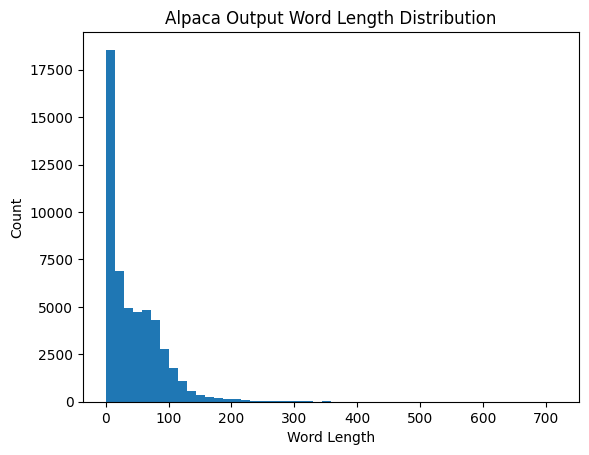

In [8]:
import matplotlib.pyplot as plt
word_lengths = [len(x.split()) for x in outputs]

print("=== Word Length Statistics ===")
print(f"Mean   : {np.mean(word_lengths):.2f}")
print(f"Median : {np.median(word_lengths):.2f}")
print(f"Min    : {np.min(word_lengths)}")
print(f"Max    : {np.max(word_lengths)}")

for p in [50, 75, 90, 95, 99]:
    print(f"P{p:<2}    : {np.percentile(word_lengths, p):.2f}")


plt.hist(word_lengths, bins=50)
plt.xlabel("Word Length")
plt.ylabel("Count")
plt.title("Alpaca Output Word Length Distribution")
plt.show()

In [9]:
def format_example(ex):
    if ex["input"]:
        user = ex["instruction"] + "\n" + ex["input"]
    else:
        user = ex["instruction"]

    return {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": user},
            {"role": "assistant", "content": ex["output"]}
        ]
    }

train_ds = split['train'].map(format_example, remove_columns=split['train'].column_names)
eval_ds = split['test'].map(format_example, remove_columns = split['test'].column_names)
TRAIN_SUBSAMPLE = 4000
EVAL_SUBSAMPLE  = 800
if TRAIN_SUBSAMPLE:
    train_ds = train_ds.shuffle(SEED).select(range(min(TRAIN_SUBSAMPLE, len(train_ds))))
if EVAL_SUBSAMPLE:
    eval_ds  = eval_ds.shuffle(SEED).select(range(min(EVAL_SUBSAMPLE, len(eval_ds))))

Map:   0%|          | 0/41601 [00:00<?, ? examples/s]

Map:   0%|          | 0/10401 [00:00<?, ? examples/s]

In [17]:
import os, gc
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, Trainer
from trl import SFTTrainer, SFTConfig
from peft import prepare_model_for_kbit_training, get_peft_model, LoraConfig
import torch


MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"
CACHE_DIR   = "./cache"
OUTPUT_ROOT = "./out_full_trl"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

LORA_CONFIG = {
    "r": 16,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "bias": "none",
    "task_type": "CAUSAL_LM",
    "target_modules": [
        "q_proj","k_proj","v_proj","o_proj",
        "gate_proj","up_proj","down_proj"
    ]
}

args = dict(
    max_length=256,
    num_train_epochs=1,
    max_steps=200,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    warmup_steps=10,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="no",
    bf16=True,
    gradient_checkpointing=True,
    report_to="none",
    seed=42,
)

In [18]:
import time

def apply_chat(e, tok):
    return tok.apply_chat_template(
        e["messages"],
        tokenize=False,
        add_generation_prompt=False
    )

def params_stats(model):
  total = sum(p.numel() for p in model.parameters())
  trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
  return {"total": total, "trainable":trainable, "ratio_pct": trainable * 100/total}

def train(qlora: bool, output_dir: str):
    gc.collect()
    torch.cuda.empty_cache()
    if qlora: print("Training QLORA")
    else: print("Training LORA")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, cache_dir=CACHE_DIR)
    if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token

    if qlora:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16
        )
        model =  AutoModelForCausalLM.from_pretrained(
            MODEL_ID,
            quantization_config=bnb_config,
            device_map="auto",
            cache_dir=CACHE_DIR
        )
        model = prepare_model_for_kbit_training(
            model, use_gradient_checkpointing=True,
            gradient_checkpointing_kwargs={"use_reentrant": False}
        )
    else:
        model =  AutoModelForCausalLM.from_pretrained(
            MODEL_ID,
            device_map="auto",
            cache_dir=CACHE_DIR,
            dtype=torch.bfloat16
        )
    model.config.use_cache = False
    model = get_peft_model(model, LoraConfig(**LORA_CONFIG))
    ps = params_stats(model)
    print(f"trainable={ps['trainable']:,} ({ps['ratio_pct']:.3f}%)")

    config = SFTConfig(
        output_dir=output_dir,
        optim="paged_adamw_8bit" if qlora else "adamw_torch",
        **args
    )
    trainer = SFTTrainer(
        model=model,
        args=config,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        processing_class=tokenizer,
        formatting_func=lambda ex: apply_chat(ex, tokenizer),
    )

    t0 = time.perf_counter()
    trainer.train()
    elapsed = time.perf_counter() - t0
    print(f"[Done] {elapsed:.1f}s")

    adapter_dir = os.path.join(output_dir, "adapter")
    model.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)

In [12]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [19]:
train(qlora=False, output_dir=os.path.join(OUTPUT_ROOT, "trl_lora"))


Training LORA


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

trainable=11,272,192 (0.904%)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss,Validation Loss
100,1.094388,1.049526
200,1.064854,1.034589


[Done] 4517.9s


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

In [22]:
from peft import PeftModel

@torch.inference_mode()
def infer(samples, adapter_dir: str, qlora: bool, max_new_tokens: int = 256):
    tok = AutoTokenizer.from_pretrained(adapter_dir)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    if qlora:
        bnb = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True
        )
        base = AutoModelForCausalLM.from_pretrained(
            MODEL_ID, quantization_config=bnb, device_map="auto")
    else:
        base = AutoModelForCausalLM.from_pretrained(
            MODEL_ID, dtype=torch.bfloat16, device_map="auto")


    model = PeftModel.from_pretrained(base, adapter_dir)
    model.eval()
    model.config.use_cache = True
    device = next(model.parameters()).device

    outs = []
    for item in samples:
        msgs = [{"role": "system", "content": "You are a helpful assistant."},
                {"role": "user",   "content": item["question"]}]
        prompt = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inp = tok(prompt, return_tensors="pt").to(device)

        out = model.generate(**inp, max_new_tokens=max_new_tokens,
                             do_sample=False, pad_token_id=tok.eos_token_id)
        prompt_len = inp["input_ids"].shape[1]
        generated = out[0][prompt_len:]

        answer = tok.decode(
            generated,
            skip_special_tokens=True
        ).strip()
        outs.append(answer)

    return outs


In [24]:
samples = [
    {"question": "What is the capital of France?"},
    {"question": "Explain LoRA finetuning in simple terms."},
    {"question": "Write a short Python function for factorial."}
]
answers = infer(
    samples=samples,
    adapter_dir="./out_full_trl/trl_lora/adapter",
    qlora=False,
    max_new_tokens=128
)
for q, a in zip(samples, answers):
    print("=" * 80)
    print("QUESTION:")
    print(q["question"])
    print()
    print("ANSWER:")
    print(a)
    print()

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

QUESTION:
What is the capital of France?

ANSWER:
The capital of France is Paris.

QUESTION:
Explain LoRA finetuning in simple terms.

ANSWER:
LoRA finetuning is a process used to improve the performance of a machine learning model by adjusting the parameters of the model to better fit the data. It involves training the model on a dataset with a specific task in mind, and then fine-tuning the model to optimize its performance on that task. This process is often used to improve the accuracy of a model, especially when the data is limited or noisy.

QUESTION:
Write a short Python function for factorial.

ANSWER:
def factorial(n):
    if n == 0:
        return 1
    else:
        return n * factorial(n-1)



In [25]:
train(qlora=True, output_dir=os.path.join(OUTPUT_ROOT, "trl_qlora"))

Training QLORA


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

trainable=11,272,192 (1.482%)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss,Validation Loss


KeyboardInterrupt: 